# VeloPotential Tutorial

## Import Packages

In [2]:
import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt
import velopotential as vp

## Load the Data
The analysis is based on a well-characterized mouse pancreatic endocrinogenesis dataset, which can be directly downloaded via a scVelo function.

In [3]:
adata = scv.datasets.pancreas()
print(adata)

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


## Generate the initial RNA velocity field

We first process the data using the standard scVelo workflow, and then generate the initial RNA velocity field using the scVelo dynamical model.

**Note:** Our tool `VeloPotential` requires precomputed velocities as input. You can use any tool to calculate the velocities; here, we use scVelo as an example.

In [4]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata, mode='dynamical')

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:10) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 1/16 cores)


  0%|          | 0/1298 [00:00<?, ?gene/s]

    finished (0:11:04) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


We project the original scVelo velocities onto the UMAP embedding. The `plot_velocity_projection` function serves as a wrapper that encapsulates calls to scVelo’s velocity_graph and velocity_embedding_stream functions.

  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


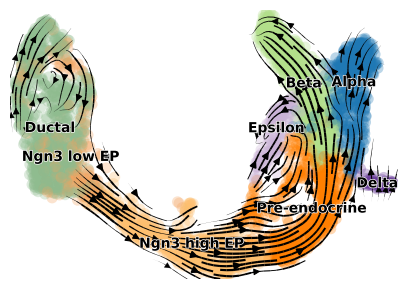

computing velocity embedding
finished.


In [5]:
vp.pl.plot_velocity_projection(adata,color="clusters",figsize=(5,3.5),xkey="Ms")

## Construct the global potential landscape and the corresponding potential-driven velocity field.
We first construct the global potential landscape and its associated potential-driven velocity field by training the `VeloPotential` model using the `construct_potential` function. By default, the inferred global potential landscape is stored in adata.obs['potential'], and the corresponding potential-driven velocity field is stored in adata.layers['velocity_pred'].

In [6]:
vp.tl.construct_potential(adata)
print(adata)

epoch   1: loss=0.459280
epoch  51: loss=0.091485
epoch 101: loss=0.084943
epoch 151: loss=0.081621
epoch 201: loss=0.080599
epoch 251: loss=0.079732
epoch 301: loss=0.078333
epoch 351: loss=0.077839
Early stopping at epoch 365
AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'potential'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    

We then project the potential-driven velocities onto the UMAP embedding.

  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


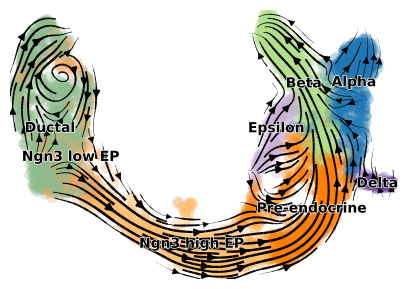

computing velocity embedding
finished.


In [7]:
vp.pl.plot_velocity_projection(adata,color="clusters",figsize=(5,3.5),vkey="velocity_pred",xkey="Ms")

We present a heatmap of the global potential landscape.

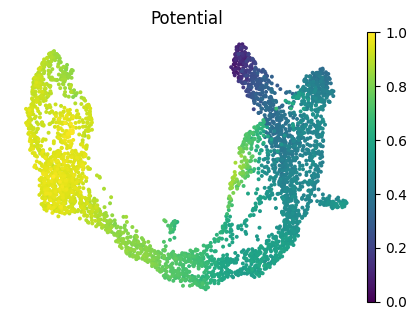

In [8]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sc.pl.umap(adata,color="potential",title="Potential",frameon=False,ax=ax)

We compute a "potential consistency score" to robustly diagnose velocity reliability at single-cell resolution.

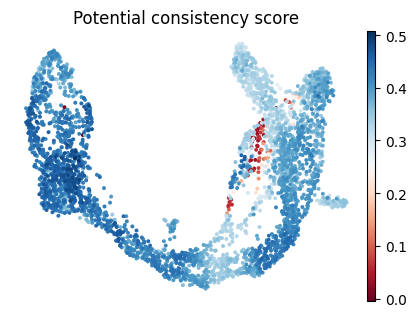

In [12]:
adata.obs['Potential consistency score'] = vp.tl.cal_cosine_similarity(adata.layers['velocity'], adata.layers['velocity_pred'])
fig, ax = plt.subplots(figsize=(5, 3.5))
sc.pl.umap(adata,color="Potential consistency score",title="Potential consistency score",frameon=False,ax=ax,cmap="RdBu")

Finally, we examine the quantitative relationship between scVelo's latent time and our inferred potential by plotting a scatter plot of the two measures.

computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


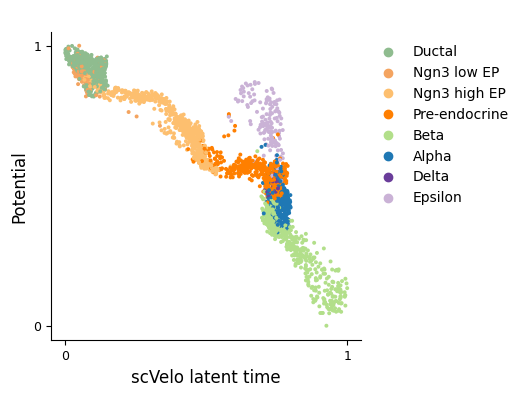

In [13]:
scv.tl.latent_time(adata)
scv.pl.scatter(adata, x='latent_time', y='potential', color='clusters',title=" ",legend_loc="upper right",fontsize=12,figsize=(4,4),xlabel="scVelo latent time",ylabel="Potential",show=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False) 
plt.show()